# Importing of Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
df = pd.read_csv(r".\Datasets\advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

# Data Cleaning

In [4]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

# Data Analysis

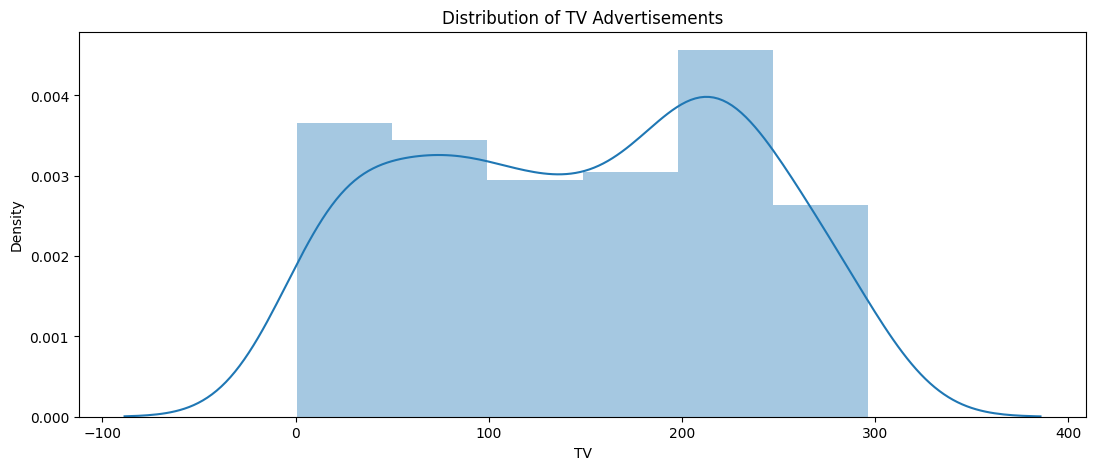

In [7]:
plt.figure(figsize = (13,5))
sns.distplot(df.TV)
plt.title("Distribution of TV Advertisements")
plt.show()

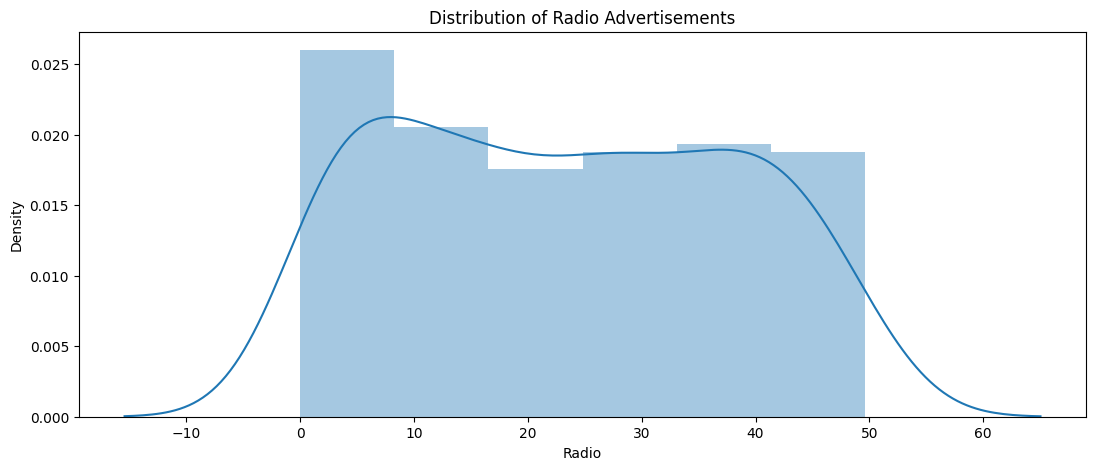

In [8]:
plt.figure(figsize = (13,5))
sns.distplot(df.Radio)
plt.title("Distribution of Radio Advertisements")
plt.show()

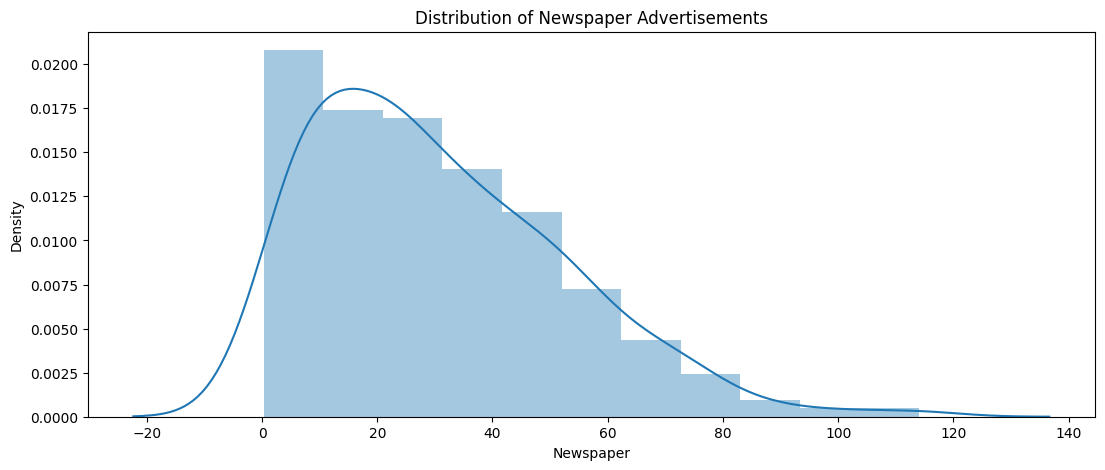

In [9]:
plt.figure(figsize = (13,5))
sns.distplot(df.Newspaper)
plt.title("Distribution of Newspaper Advertisements")
plt.show()

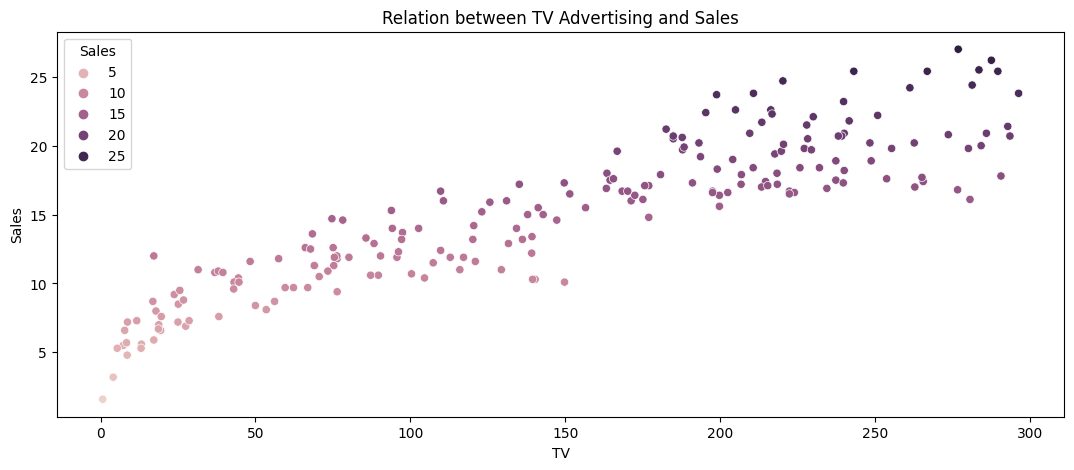

In [10]:
plt.figure(figsize = (13,5))
sns.scatterplot(data = df, x = 'TV', y = 'Sales', hue = df.Sales)
plt.title('Relation between TV Advertising and Sales')
plt.show()

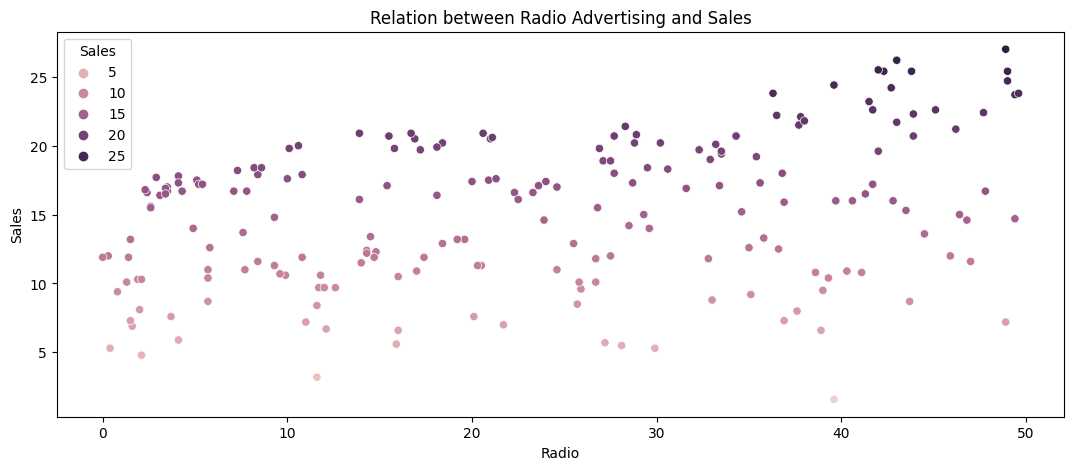

In [11]:
plt.figure(figsize = (13,5))
sns.scatterplot(data = df, x = 'Radio', y = 'Sales', hue = df.Sales)
plt.title('Relation between Radio Advertising and Sales')
plt.show()

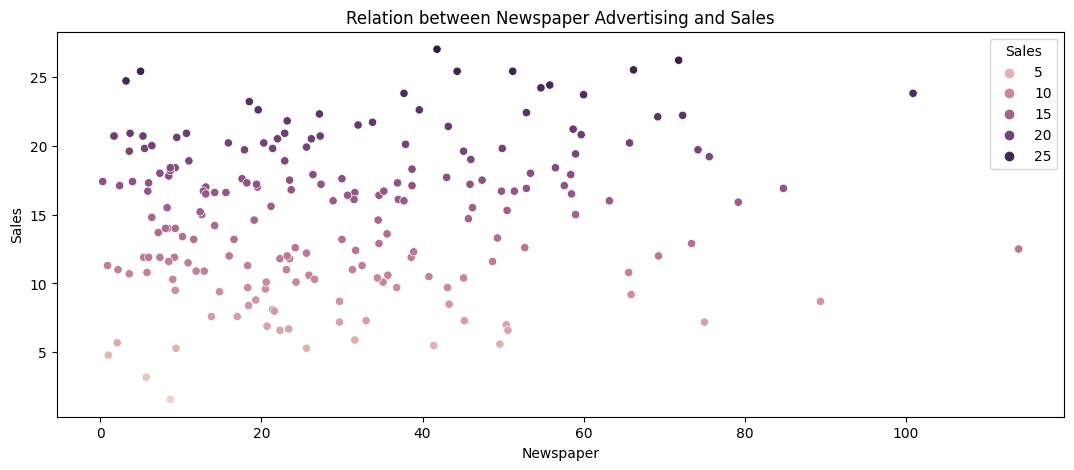

In [12]:
plt.figure(figsize = (13,5))
sns.scatterplot(data = df, x = 'Newspaper', y = 'Sales', hue = df.Sales)
plt.title('Relation between Newspaper Advertising and Sales')
plt.show()

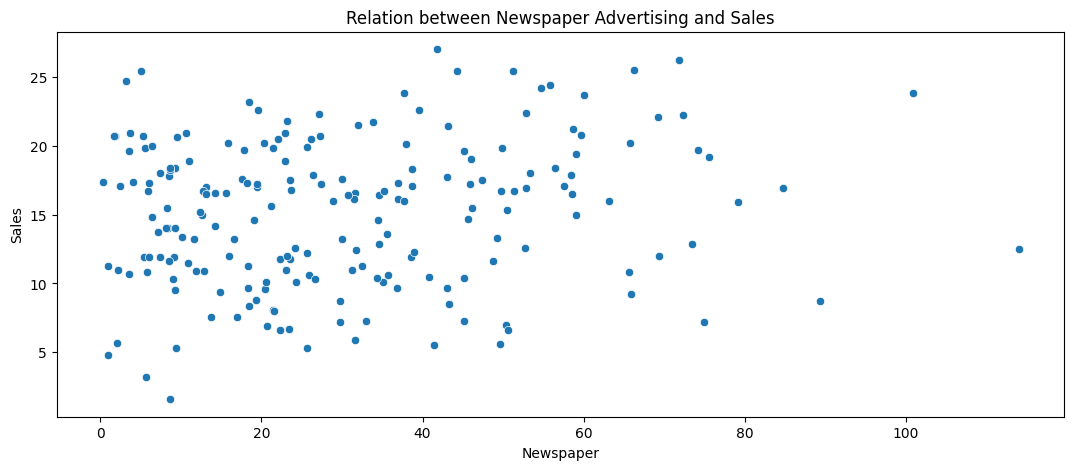

In [13]:
plt.figure(figsize = (13,5))
sns.scatterplot(data = df, x = 'Newspaper', y = 'Sales')#, hue = df.Sales)
plt.title('Relation between Newspaper Advertising and Sales')
plt.show()

In [14]:
df_corr = df.corr()
df_corr

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


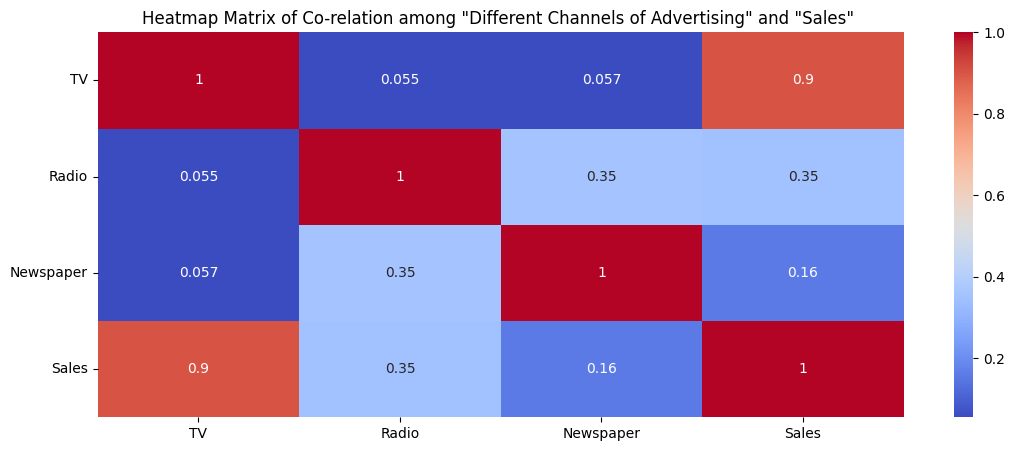

In [15]:
plt.figure(figsize = (13,5))
sns.heatmap(df_corr, annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.title('Heatmap Matrix of Co-relation among "Different Channels of Advertising" and "Sales" ')
plt.show()

# Input & Output Creation

In [16]:
ip = df.drop(['Sales'], axis = 1)
ip

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [17]:
op = df['Sales']
op

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

# Train Test Split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.8)

In [19]:
df.shape, x_train.shape, x_test.shape

((200, 4), (160, 3), (40, 3))

# Standard Scaler Transform

In [20]:
sc = StandardScaler()
sc

StandardScaler()

In [21]:
x_train = sc.fit_transform(x_train)
x_train

array([[ 0.84359614,  0.61748925,  0.58740911],
       [ 0.77048341,  1.26119247,  0.08436076],
       [ 0.95616653,  0.53617937,  1.8828699 ],
       [-0.51537221,  0.35323214, -1.04638508],
       [-0.61749792,  1.29507158,  0.82780389],
       [-1.60974211,  0.19061238, -1.32684566],
       [ 0.21459456, -0.97482923, -0.63682359],
       [-0.59080598, -0.64958971,  0.31140028],
       [ 1.34378005, -1.41525775, -0.55224024],
       [-1.55519769, -1.62530827, -0.28068317],
       [ 0.98634004, -1.06969076, -1.03302981],
       [-1.51109795,  1.30862323,  2.5595367 ],
       [-1.14669482,  1.5322254 , -1.04193332],
       [ 0.72522315, -0.25659196, -0.94399471],
       [-0.93083819, -0.85964024,  0.21791342],
       [ 1.66640447, -1.37460281, -1.04193332],
       [ 1.55035252, -0.71057212,  0.22681693],
       [ 0.2285208 ,  1.19343423, -1.26006933],
       [-1.05501378, -1.26618964, -0.0981612 ],
       [-0.36102311, -1.13067317, -0.39197705],
       [ 0.51052704,  0.29224973, -0.610

In [22]:
x_test = sc.fit_transform(x_test)
x_test

array([[-0.08716675, -1.17840836,  0.08305052],
       [-0.44290053,  2.05165684,  1.50350079],
       [-1.22264021,  0.49670204, -0.2606068 ],
       [ 0.9764413 , -0.13234786,  0.06014003],
       [ 1.11418333, -1.03704883,  0.67299559],
       [-0.92918979,  0.12209929, -0.39234211],
       [ 0.55602866, -0.02632821,  2.32255074],
       [ 0.85906113, -0.94516514,  0.1288715 ],
       [-1.4585983 , -0.54935846,  0.2606068 ],
       [ 0.66742004,  0.24932287,  0.36943162],
       [ 1.66754698, -0.34438715, -1.22857493],
       [ 0.0362022 , -1.23495217, -0.04868479],
       [ 0.63508061, -1.14306848, -0.22624107],
       [ 0.49254755, -0.11114393, -0.4152526 ],
       [-1.69335864,  0.78648907, -0.90210047],
       [-0.67526535, -1.30563193, -0.11168863],
       [ 0.90577365, -1.08652467, -0.69017846],
       [-1.01183501, -0.43627084, -0.39234211],
       [ 0.45661484,  1.77600576, -1.34312737],
       [-0.85852214,  1.14695586,  1.57795988],
       [ 0.00625828,  0.36241049, -0.346

# Implementation of ML Model

In [23]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

# Prediction

In [24]:
ycap = lr.predict(x_test)
ycap

array([12.83748352, 16.57588244, 10.43329123, 19.68090679, 18.67542132,
       11.18614084, 17.570155  , 17.70481664,  7.4300174 , 18.84250498,
       22.75242773, 13.33984053, 16.35185175, 17.49776433,  8.80180347,
        9.86593037, 17.79188687,  9.82562348, 20.73428221, 13.03098061,
       16.01485074, 22.37441986, 20.64494071, 18.08050261,  9.73717071,
        9.15914842, 15.1023892 , 19.95772494, 24.49262623, 10.34461054,
       16.3973726 , 19.1669791 , 10.42467604, 23.45991863, 22.60416048,
        9.00632413, 11.28951344, 16.00116559,  7.40472321,  9.73277131])

In [25]:
pdf = pd.DataFrame({'y':list(y_test),
                    'prediction':ycap})
pdf

,y,prediction
0,10.3,12.837484
1,16.7,16.575882
2,10.1,10.433291
3,20.5,19.680907
4,17.3,18.675421
5,11.3,11.186141
6,20.2,17.570155
7,17.2,17.704817
8,7.2,7.430017
9,16.6,18.842505


# Accuracy & Error Scores

In [26]:
mse = mean_squared_error(y_test, ycap)
print("Mean Squared Error: ", mse)

Mean Squared Error:  5.974739099229969


In [27]:
r2 = r2_score(y_test, ycap)
print("R2 Score:", r2)
print("Accuracy:", r2*100)

R2 Score: 0.7502418642497954
Accuracy: 75.02418642497955


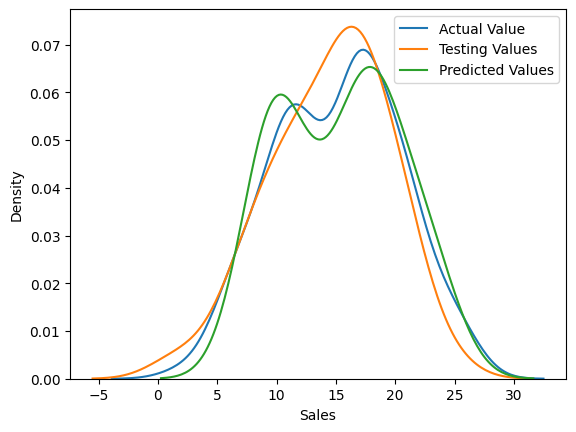

In [28]:
sns.kdeplot(df["Sales"], label = "Actual Value")
sns.kdeplot(y_test, label = "Testing Values")
sns.kdeplot(ycap, label = "Predicted Values")
plt.legend()
plt.show()

In [29]:
xn = np.array([94.2, 4.2, 8.1]).reshape(1,-1)
sc.fit(xn)
xn = sc.transform(xn)
lr.predict(xn)

array([15.308125])